# PROJET STOCK MARKET - PREDICTION DE EARNINGS


# Introduction

L'objectif de ce notebook est d'évaluer le meilleur modèle d'apprentissage supervisé pour la prédiction des earnings du S&P 500. Pour cela, nous allons explorer plusieurs architectures étudiées dans le cours de modélisation statistique, à savoir la régression linéaire simple et la régression linéaire multiple.
Ensuite, nous développerons deux modèles de deep learning : un réseau neuronal simple et un réseau basé sur des couches LSTM.
Enfin, nous analyserons comment les données réagissent à ces modèles à l'aide de visualisations et de métriques telles que le MAE et la fonction de perte (loss).

# 1. Outils

Cette partie présente les outils nécessaires à notre étude, notamment les librairies utilisées, les paramètres ainsi que les fonctions. Ensuite, les données sont importées depuis notre base de données SQL fournie sur notre GitHub.

## 1.1 Librairies 

In [81]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from data_windowing import WindowGenerator

import graphviz





## 1.2 Parametres

In [82]:

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_WIDTH = 5
LABEL_WIDTH = 1
SHIFT = 1

P_VAL = 0.1
P_TEST = 0.1

EPOCHS = 40
BATCH_SIZE = 12

FIGSIZE = (12, 6)




## 1.3 Connexion a la base de donnees

In [83]:
config = {
    "user": "root",
    "password": "root",
    "host": "localhost",
    "database": "sdd4",
    "raise_on_warnings": True
}

bdd = mysql.connector.connect(**config)


## 1.4 Fonctions

### 1.4.1 Importation des donnees 

In [84]:

def import_financialbehavior_table(bdd)->pd.DataFrame:
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM financial_behavior")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df = df.set_index("idTB")

    return df 

def import_tweets_table(bdd) -> pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM tweets")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("idT")

    return df 

def import_bigmacindex_table(bdd) -> pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM bigmacindex")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    for columns in df.columns: 
        if columns != "observation_date": 
            df[columns] = df[columns].astype(float)
    df = df.set_index("idBM")

    return df 

def import_bitcoinperformance_table(bdd) ->pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM bitcoinperformance")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    for columns in df.columns: 
        if columns != "observation_date": 
            df[columns] = df[columns].astype(float)
    df = df.set_index("idB")

    return df 

def import_sp500_table(bdd)->pd.DataFrame:
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM standardandpoor")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("idSP")

    return df

def import_inflation_table(bdd) ->pd.DataFrame:

    cursor = bdd.cursor()
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM inflation")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns=columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df["CPI"] = df["CPI"].astype(float)
    df = df.set_index("idI")

    return df

def import_joinTable(bdd,*args:pd.DataFrame): 
    df = import_sp500_table(bdd)
    for table in args: 
        df = df.merge(table,on = "observation_date",how = "inner")

    
    return df

def standar_df(df:pd.DataFrame): 
    for columns in df.columns: 
        df[columns] = (df[columns] - df[columns].mean())/df[columns].std()
    
    return df



### 1.4.2 Fonctions de plotting 

In [85]:

df = import_sp500_table(bdd)

MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()
    
def plot_prediction(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.training_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.training_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.test_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.test_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test_general(wg: WindowGenerator, model: tf.keras.Sequential,label_encoder:int = None,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):
    
    if label_encoder is not None:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width,2)
    else:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width)

    plt.figure(figsize=FIGSIZE)

    y_pred = model.predict(x).flatten()
    y_pred = (y_pred + mean) * std  

    y_real = y.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()


def plot_bar_metrics(metrics:str,models:dict,title:str = None):
    plt.figure(figsize=FIGSIZE)
    height = []
    for keys in models.keys():
        if keys != "Baseline":
            height.append(models[keys].history[metrics][-1])
        else:
            height.append(models[keys][metrics])
    plt.bar(models.keys(),height)

    if title: 
        plt.title(title)
    else:
        plt.title(f"{metrics} of models")

    plt.show()

def plot_training_validation(history:dict,metrics:str,title:str = None): 
    plt.figure(figsize=FIGSIZE)

    if metrics == "loss":
        plt.plot(history["val_loss"],label="val loss")
        plt.plot(history["loss"],label = "loss")
    elif metrics == "mae": 
        plt.plot(history["mae_loss"],label="mae loss")
        plt.plot(history["mae"],label = "mae")

    if title:
        plt.title(title)
        
    plt.legend()
    plt.show()

# 2. Modeles 


## 2.1 Pretraitement de données 

Pour réaliser du forecasting, il est nécessaire de traiter les données d’une manière spécifique. Les algorithmes apprennent généralement à l’aide de fenêtres (windows). Une fenêtre consiste à prendre une séquence de données, par exemple les données du S&P 500 du lundi au mardi comme variables d’entrée, et celles du mercredi comme variable cible pour l’entraînement.
Dans cette perspective, on introduit également la notion de shift, qui correspond au décalage temporel entre chaque fenêtre. Dans cette étude, comme nous travaillons avec des modèles de régression linéaire, et par convention, nous utilisons un shift de 1. 

Avant d’effectuer le windowing, nous allons standardiser les données afin de les convertir en z-scores. Le z-score est une mesure qui représente l’écart d’une observation par rapport à la moyenne générale, exprimé en nombre d’écarts-types. Par exemple, une valeur de -1 indique que l’observation se situe un écart-type en dessous de la moyenne (la moyenne étant égale à 0 après standardisation).Cette transformation permet aux algorithmes d’analyser les données sans rencontrer de problèmes d’échelle.

In [86]:
sp = standar_df(df.copy())

target_col = "earnings"

features = [
    "sp500",
    "dividend",
    "earnings",
    "longInterestRate"
]

df_model = sp[features].copy()

df_model




,sp500,dividend,earnings,longInterestRate
idSP,,,,
2,-0.461055,-0.528404,-0.496333,0.367589
3,-0.461074,-0.528404,-0.496333,0.361070
4,-0.460938,-0.528404,-0.496333,0.365416
5,-0.460777,-0.528404,-0.496333,0.365416
6,-0.460629,-0.528404,-0.496333,0.365416
...,...,...,...,...
1830,4.658198,4.392132,4.579796,-0.399512
1831,4.904417,4.404383,4.636586,-0.321281
1832,5.105533,4.404383,4.636586,-0.256088


## 2.1.2 Window Generator 

Sur notre GitHub, vous pouvez retrouver la classe WindowGenerator que nous avons développée afin de créer les fenêtres nécessaires à la préparation des données.
Nous définissons trois objets WindowGenerator. Un pour les modèles régression linéaire multiple et les réseaux de neurones dense, pour lesquels les données doivent être présentées sous forme de matrices 2D (observations × variables), un autre pour le modèle LSTM, qui nécessite des données sous forme de tenseurs 3D (observations × pas de temps × variables).
Cette distinction est essentielle, car les modèles séquentiels comme les LSTM exploitent explicitement la dimension temporelle, contrairement aux modèles linéaires et aux réseaux dense. Pour finir, un pour la régression linéaire simple avec une seule variable .

In [87]:
target_index = df_model.columns.get_loc(target_col)

wg_lstm = WindowGenerator(
    df=df_model,
    input_width=INPUT_WIDTH,
    shift=SHIFT,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=LABEL_WIDTH,
    label_encoder= target_index
)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

wg_linear_uni_variable = WindowGenerator(
    df=df_model["earnings"],
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
)



In [88]:

print(wg_linear.training_label.shape)
print(wg_linear.training_input.shape)

(1464,)
(1464, 4)


In [89]:
print(wg_lstm.training_label.flatten().shape)
print(wg_lstm.training_input.shape)

(1460,)
(1460, 5, 4)


# 3. Modeles

## 3.1 Baseline

Afin d’évaluer si notre modèle a correctement appris à partir des données d’entraînement, nous avons défini un baseline predictor. Il s’agit d’un modèle naïf pour lequel la prédiction à l’instant 𝑡+1t+1 est simplement égale à la valeur observée à l’instant t.


In [90]:


class BaselinePredictor:

    def __init__(self, shift: int = 1, target_index: int = 0):
        self.shift = shift
        self.target_index = target_index

    def fit(self, X: np.ndarray, y: np.ndarray):
        
        self.X_train_ = X
        self.y_train_ = y
    
        if self.shift == 1:
            y_pred = X[-1,self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

        y_pred = y_pred.reshape(-1)
        y_true = y.flatten()

        loss = np.mean((y_true - y_pred) ** 2)
        mae = np.mean(np.abs(y_true - y_pred))

        self.history = {'loss': loss, 'mae': mae}

        return self.history


    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.shift == 1:
            y_pred = X[-1, self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

 
        return y_pred
        






## 3.2 Modèles d’apprentissage supervisé

Le premier modèle est la régression linéaire. Pour la régression linéaire simple ou multiple avec TensorFlow, la seule chose qui change est l’input, donc il ne faut pas créer plusieurs fonctions.


$$
y = \beta_0 + \beta_1 x + \varepsilon
$$


$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \varepsilon
$$

In [91]:

def build_linear_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


Le réseau neuronal reste le modèle de deep learning le plus simple. Dans cette architecture, nous avons choisi une seule couche de 32 neurones avec la fonction d’activation ReLU.

$$
\text{ReLU}(x) =
\begin{cases} 
0 & \text{si } x < 0 \\[2mm]
x & \text{si } x \ge 0
\end{cases}
$$

In [133]:


def build_dense_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

build_linear_model(wg_linear.training_input.shape[1:]).summary()



Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

Pour comprendre les LSTM (Long Short-Term Memory), il s’agit d’un type de réseau de neurones récurrent (RNN, Recurrent Neural Network) conçu pour mieux gérer les dépendances temporelles dans les données.
Dans le cas de la prédiction d’un stock, les données récentes ont généralement plus d’importance que celles d’il y a 50 ans.
L’idée générale d’une LSTM est de posséder un cell state qui agit comme une mémoire, permettant d’agréger et de conserver l’information pertinente sur l’ensemble des séquences temporelles, tout en filtrant ce qui est moins important.

Pour cela, on utilise la fonction tanh, qui permet de normaliser les valeurs du cell state entre -1 et 1. L’objectif est de déterminer si une variable doit être intégrée dans ce cell state : si la valeur est inférieure à 0, elle n’est pas prise en compte.

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

Pour finir, nous avons utilisé le dropout, une méthode de régularisation permettant d’éviter le overfitting. Le dropout consiste à éliminer aléatoirement une partie des neurones pendant l’entraînement. Ici nous avons appliqué un taux de 20 % aprés chaque LSTM pour favoriser la généralisation du modèle.

In [135]:

def build_lstm_model(input_shape):
        
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(32, activation='tanh',return_sequences=True),  
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32, activation='tanh'), 
        tf.keras.layers.Dropout(0.2), 

        tf.keras.layers.Dense(1)             
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

build_lstm_model(wg_lstm.training_input.shape[1:]).summary()


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 32)          │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,089 (51.13 KB)

 Trainable params: 13,089 (51.13 KB)

 Non-trainable params: 0 (0.00 B)

## 3.3 Callback

Notre problème principal dans ce notebook est le surapprentissage. Pour l’éviter, il faut faire attention au nombre d’epochs effectuées. Si le MAE de validation commence à augmenter, continuer l’entraînement n’a aucun sens, car cela signifie que le modèle s’adapte trop aux données d’entraînement.
Notre objectif est d’obtenir un MAE de validation qui converge vers celui de l’entraînement. Pour cela, nous avons utilisé un callback. Le callback est une classe qui surveille l’entraînement et peut l’interrompre automatiquement si la perte de validation (val loss) continue d’augmenter après un certain nombre d’itérations.

In [95]:
class StopIfValLossRepeated(tf.keras.callbacks.Callback):

    def __init__(self, max_repeats=3):
        super().__init__()
        self.max_repeats = max_repeats
        self.last_val_loss = None
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_loss = logs.get("val_loss")

        
        if self.last_val_loss is not None and current_val_loss >= self.last_val_loss:
            self.counter += 1
        else:
            self.counter = 0 

        self.last_val_loss = current_val_loss

        if self.counter >= self.max_repeats:
            print("Stopping: val_loss repeated too many times")
            self.model.stop_training = True
            self.last_val_loss = None
            self.counter = 0

callback = StopIfValLossRepeated(max_repeats=10)

## 3.4 Entraînement et visualisation

In [96]:
model = BaselinePredictor()
history_baseline = model.fit(wg_linear.training_input,wg_linear.training_label)

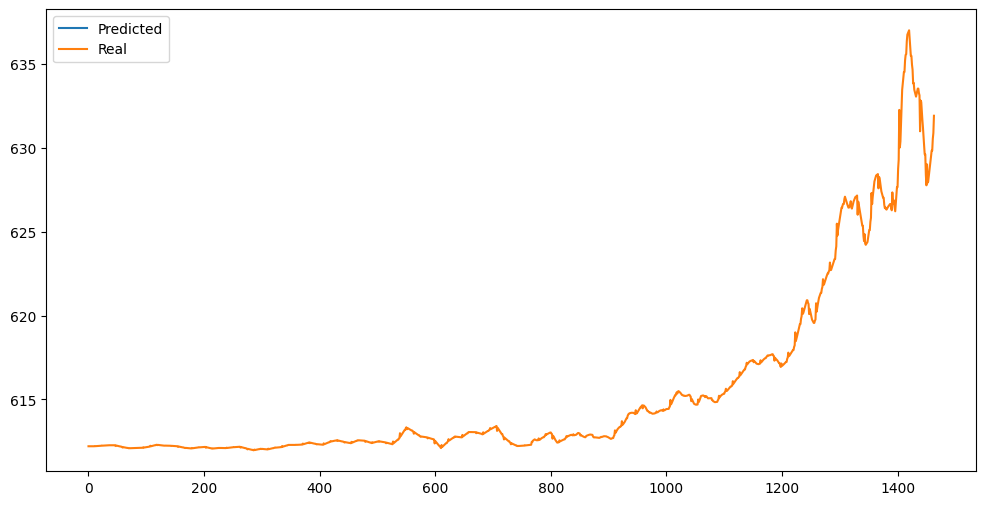

In [97]:
plot_prediction(wg_linear,model)

In [98]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1558 - mae: 0.8547 - val_loss: 3.1898 - val_mae: 1.4610
Epoch 2/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7461 - mae: 0.6304 - val_loss: 2.7156 - val_mae: 1.3521
Epoch 3/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4820 - mae: 0.4730 - val_loss: 2.4050 - val_mae: 1.2785
Epoch 4/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3170 - mae: 0.3616 - val_loss: 2.2297 - val_mae: 1.2386
Epoch 5/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2131 - mae: 0.2841 - val_loss: 2.1578 - val_mae: 1.2279
Epoch 6/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1451 - mae: 0.2328 - val_loss: 2.1566 - val_mae: 1.2437
Epoch 7/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0989 - mae: 0.1952 - val_loss: 2.1971 - val_mae: 1.2726
Epoch 8/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0669 - mae: 0.1629 - val_loss: 2.2559 - val_mae: 1.3034
Epoch 9/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


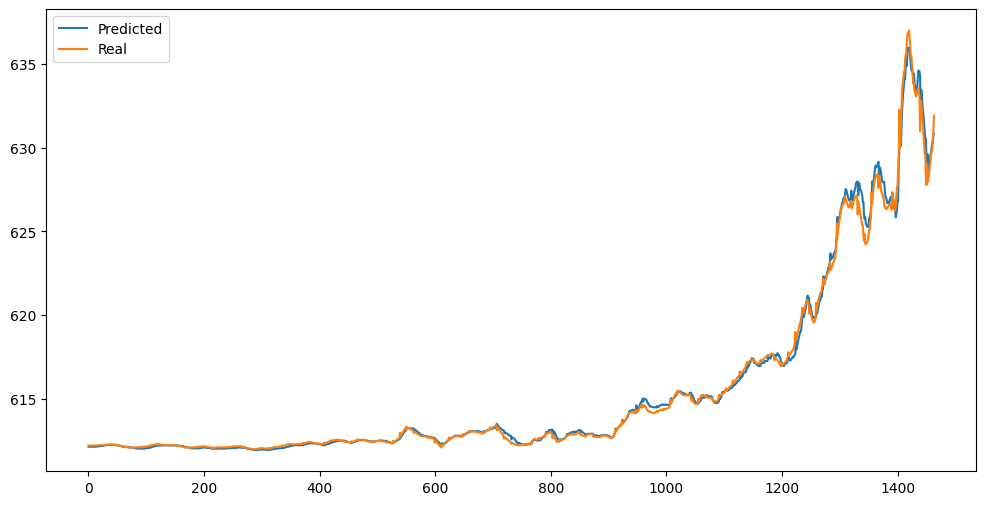

In [99]:
plot_prediction(wg_linear,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


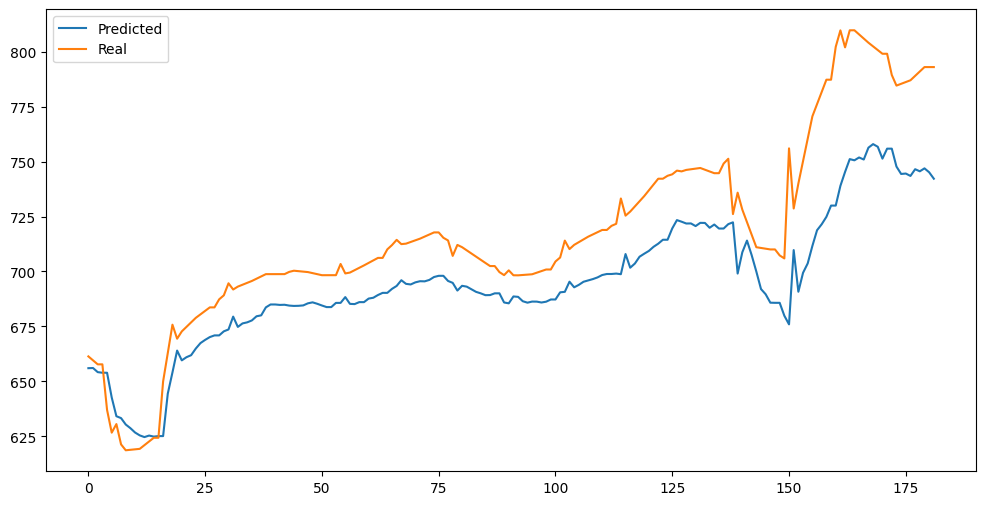

In [100]:
plot_prediction_test(wg_linear,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


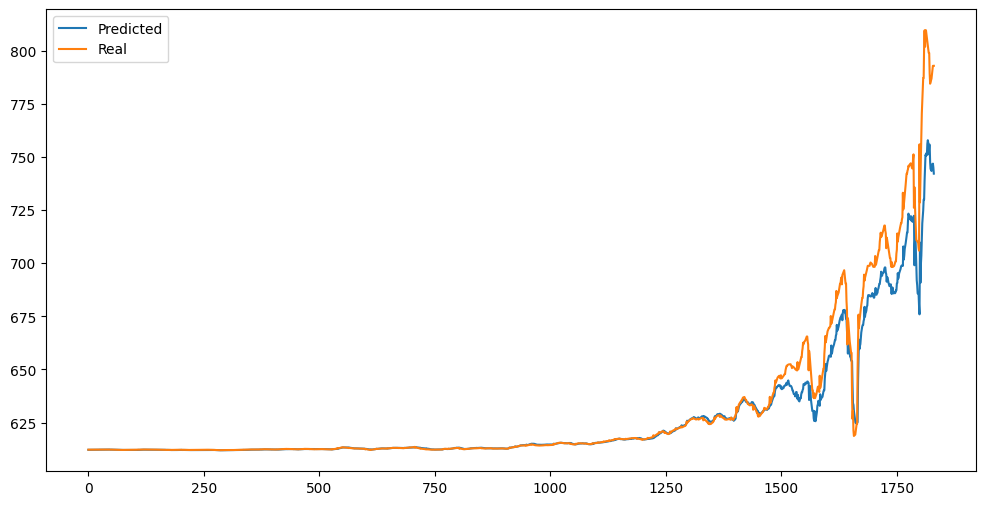

In [101]:
plot_prediction_test_general(wg_linear,model,2)

In [102]:


model = build_linear_model(wg_linear_uni_variable.training_input.reshape(-1, 1).shape[1:])
history_linear_uni = model.fit(wg_linear_uni_variable.training_input.reshape(-1, 1),wg_linear_uni_variable.training_label,
                               epochs= 80 ,validation_data=(wg_linear_uni_variable.val_input, wg_linear_uni_variable.val_label), batch_size= BATCH_SIZE,callbacks=[callback])

Epoch 1/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5052e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0413
Epoch 2/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4616e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 3/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4639e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 4/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4646e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 5/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4650e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 6/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4652e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 7/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4653e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 8/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.4655e-05 - mae: 0.0024 - val_loss: 0.0058 - val_mae: 0.0412
Epoch 9/80
122/122 ━━━━━

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


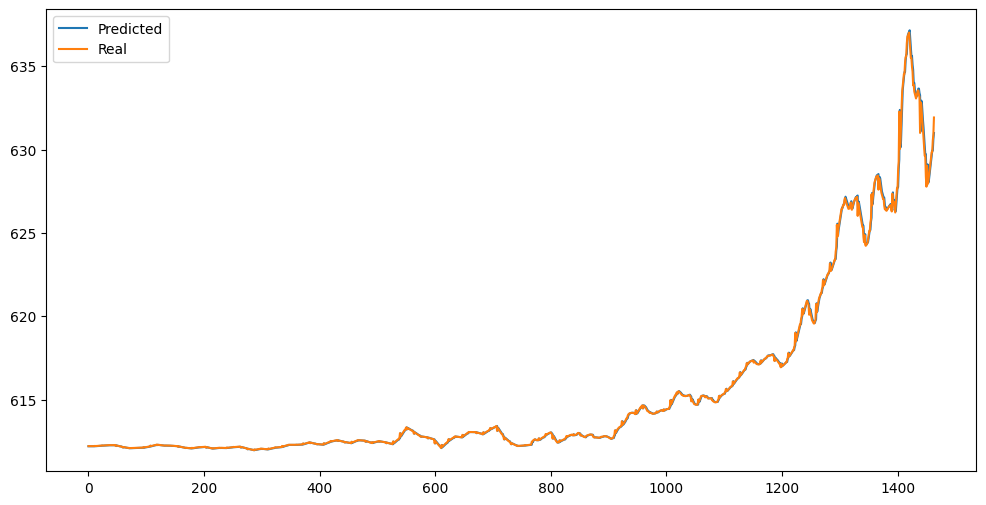

In [103]:
plot_prediction(wg_linear_uni_variable,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


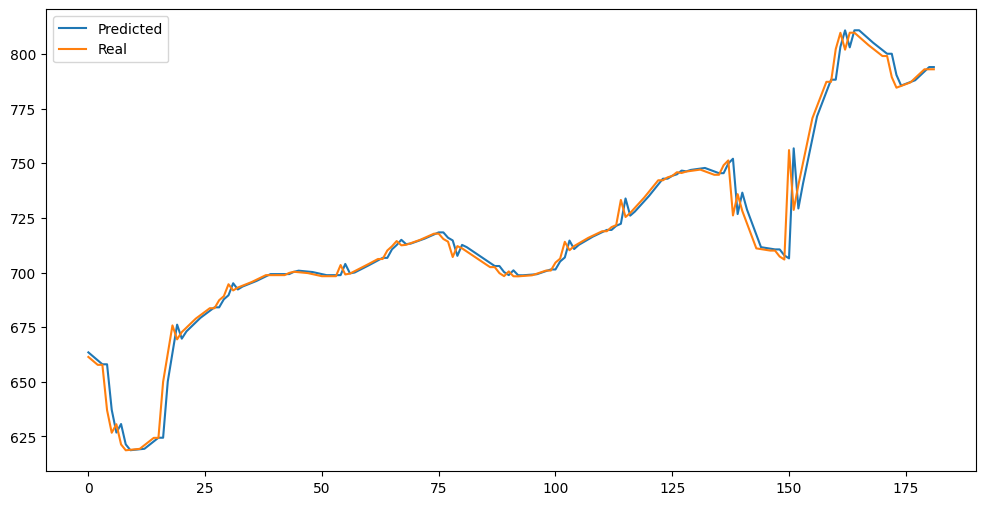

In [104]:
plot_prediction_test(wg_linear_uni_variable,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step


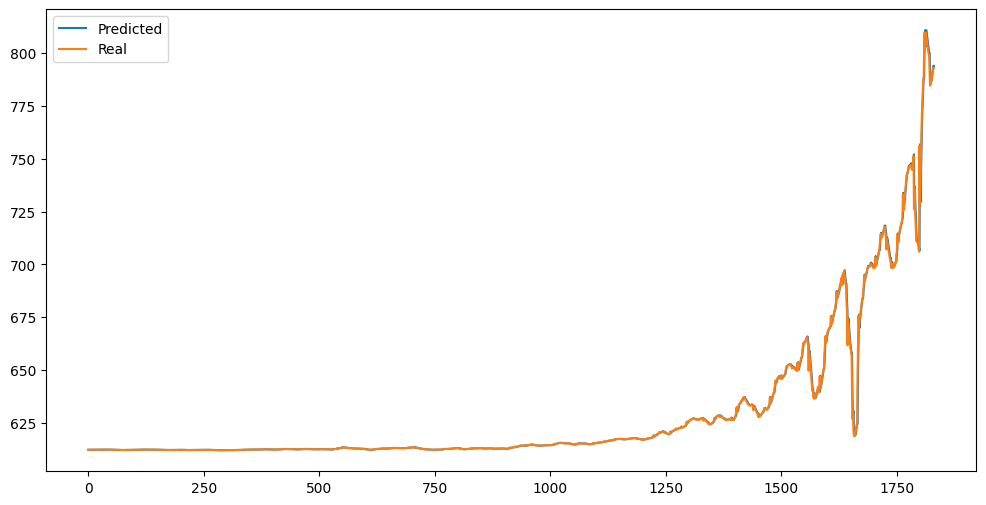

In [105]:
plot_prediction_test_general(wg_linear_uni_variable,model)

In [106]:
model = build_dense_model(wg_linear.training_input.shape[1:])
history_dense = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= EPOCHS,
                          validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1754 - mae: 0.3213 - val_loss: 0.4920 - val_mae: 0.5853
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0380 - mae: 0.1527 - val_loss: 0.4617 - val_mae: 0.5623
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0274 - mae: 0.1280 - val_loss: 0.4402 - val_mae: 0.5506
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0211 - mae: 0.1095 - val_loss: 0.4225 - val_mae: 0.5409
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0157 - mae: 0.0968 - val_loss: 0.3978 - val_mae: 0.5260
Epoch 6/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0125 - mae: 0.0885 - val_loss: 0.3639 - val_mae: 0.5034
Epoch 7/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0104 - mae: 0.0800 - val_loss: 0.3492 - val_mae: 0.4957
Epoch 8/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0090 - mae: 0.0741 - val_loss: 0.3269 - val_mae: 0.4803
Epoch 9/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


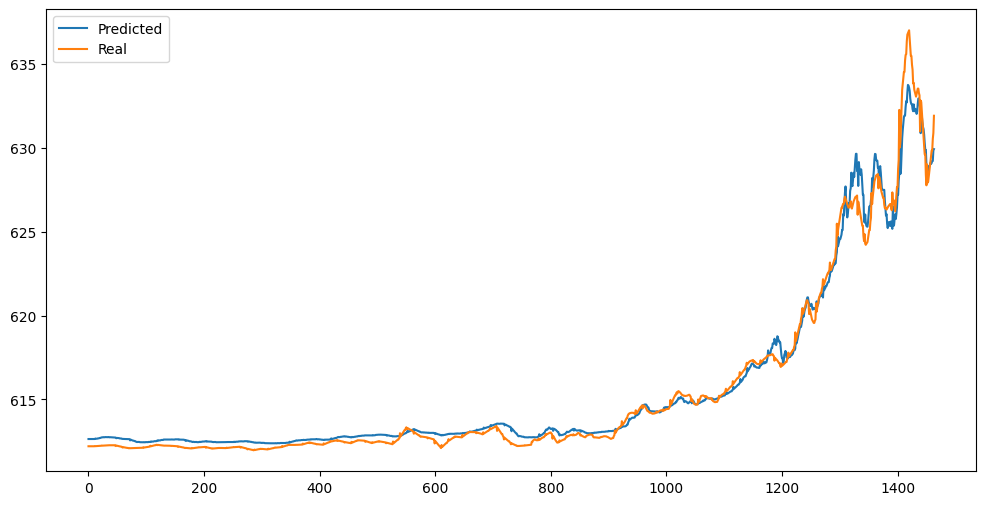

In [107]:
plot_prediction(wg_linear,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


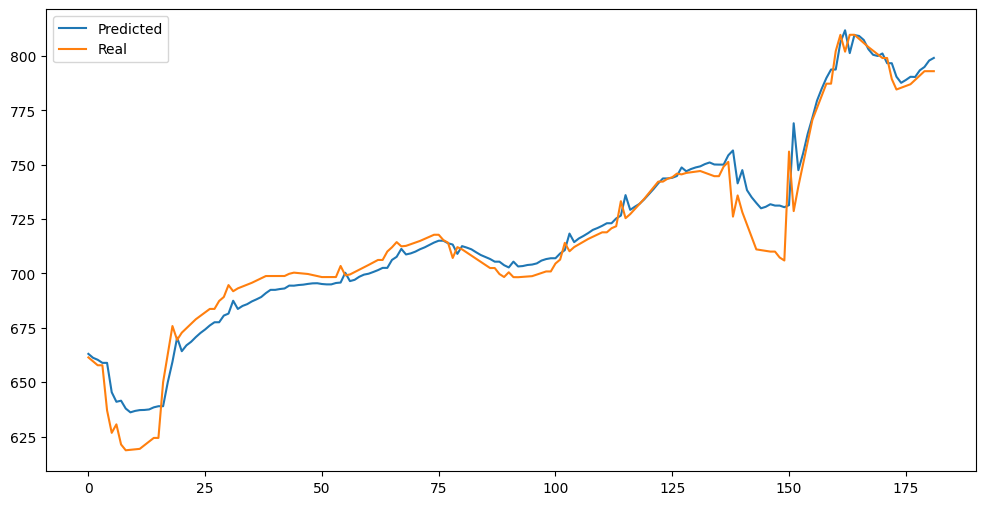

In [108]:
plot_prediction_test(wg_linear,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


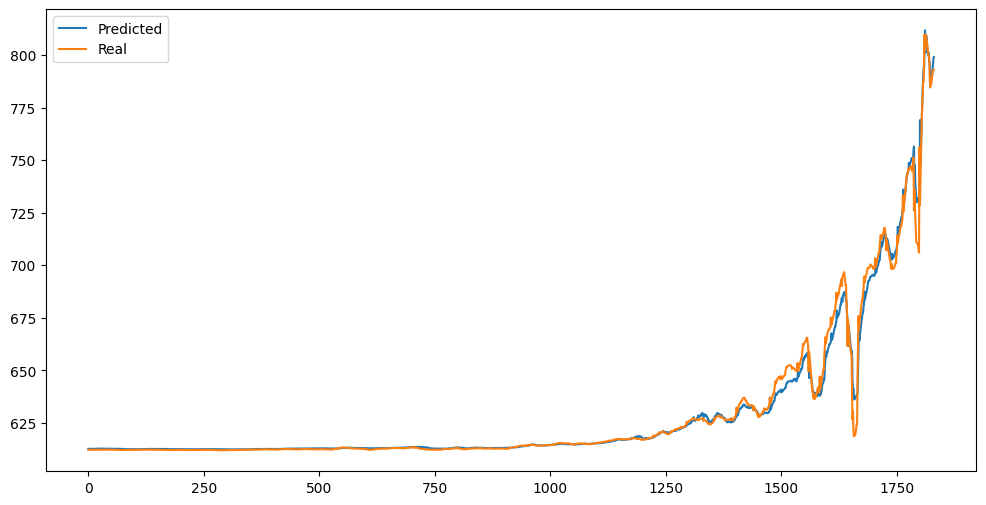

In [109]:
plot_prediction_test_general(wg_linear,model,2)

In [110]:
model = build_lstm_model(wg_lstm.training_input.shape[1:])
history_lstm = model.fit(wg_lstm.training_tf,validation_data=wg_lstm.val_tf,epochs= EPOCHS,callbacks=[callback])

Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0505 - mae: 0.1763 - val_loss: 0.4556 - val_mae: 0.5673
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0163 - mae: 0.1073 - val_loss: 0.3930 - val_mae: 0.5215
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088 - mae: 0.0747 - val_loss: 0.3792 - val_mae: 0.5136
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082 - mae: 0.0727 - val_loss: 0.3386 - val_mae: 0.4783
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - mae: 0.0614 - val_loss: 0.3489 - val_mae: 0.4896
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - mae: 0.0643 - val_loss: 0.3017 - val_mae: 0.4480
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - mae: 0.0540 - val_loss: 0.3065 - val_mae: 0.4545
Epoch 8/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - mae: 0.0556 - val_loss: 0.2689 - val_mae: 0.4207
Epoch 9/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - mae:

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


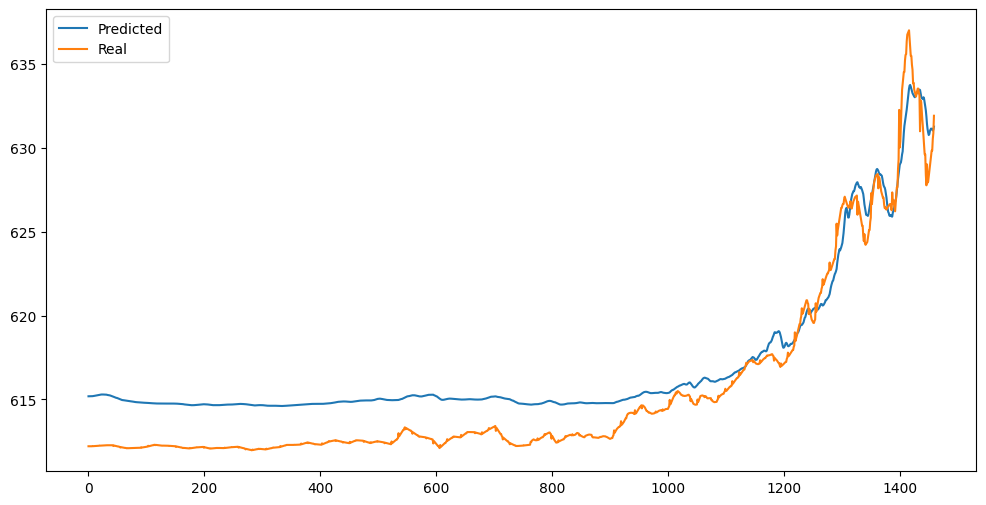

In [111]:
plot_prediction(wg_lstm,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


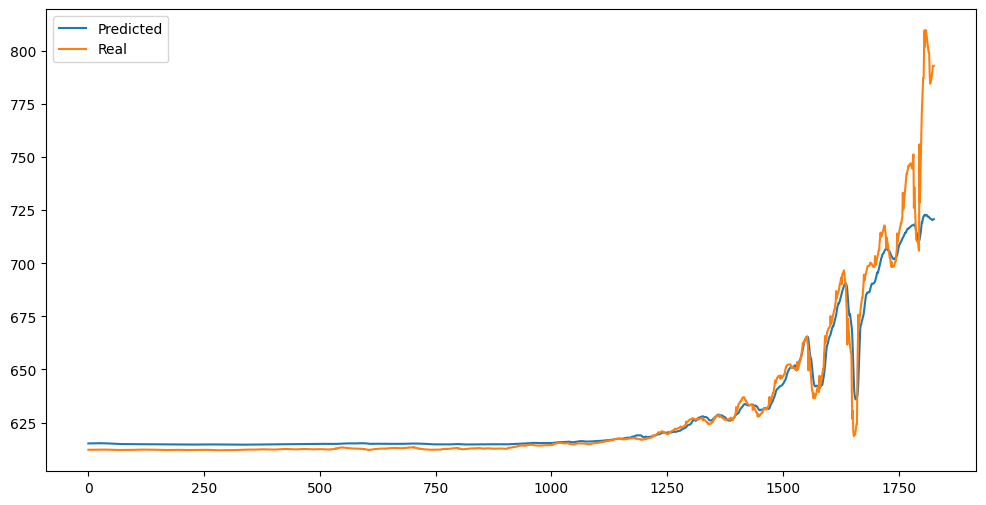

In [112]:
plot_prediction_test_general(wg_lstm,model,2)

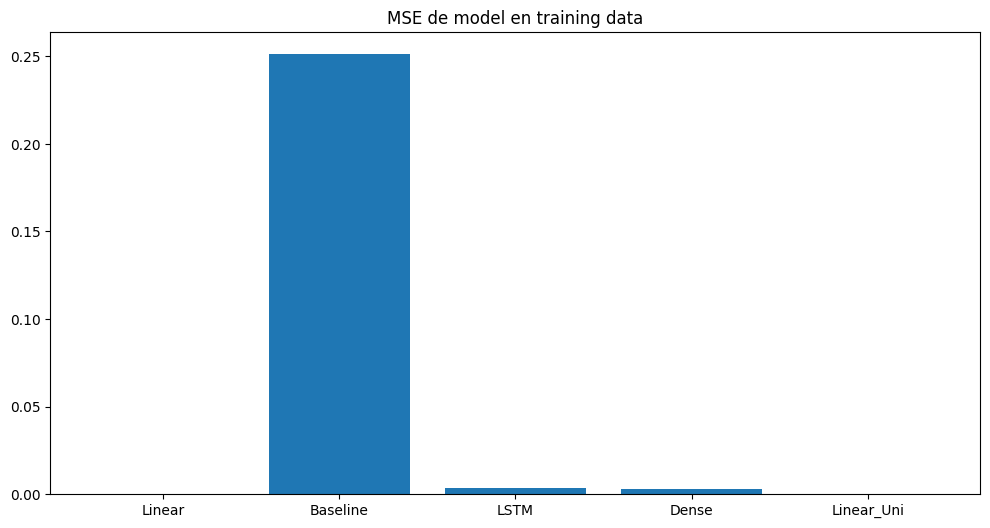

In [113]:
models = {
    "Linear": history_linear,
    "Baseline": history_baseline,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}



models_val = {
    "Linear": history_linear,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}

plot_bar_metrics("loss", models,"MSE de model en training data")

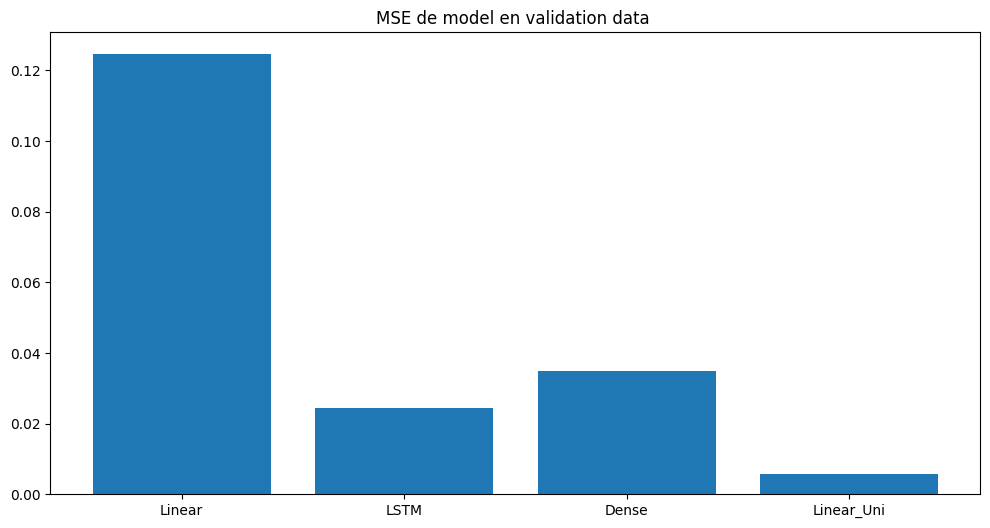

In [114]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

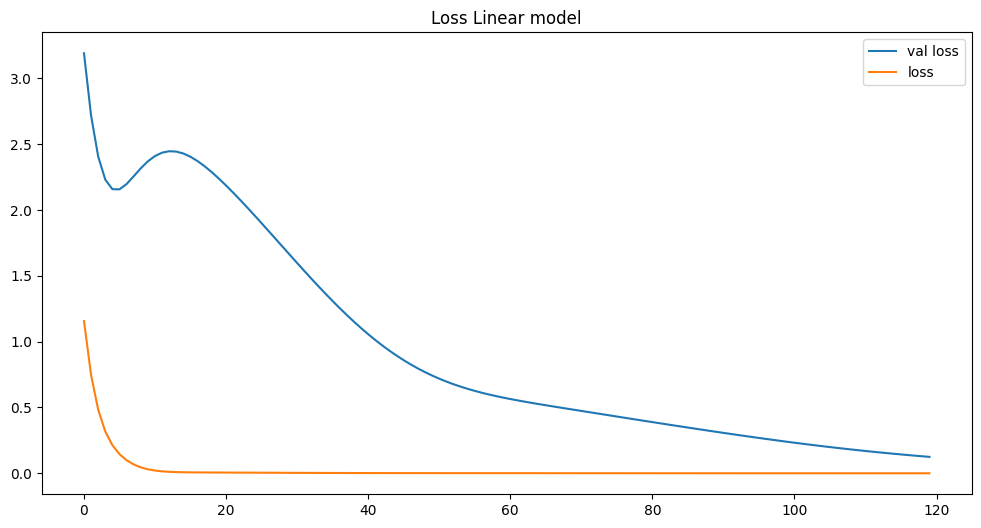

In [115]:
plot_training_validation(models_val["Linear"].history,"loss","Loss Linear model")

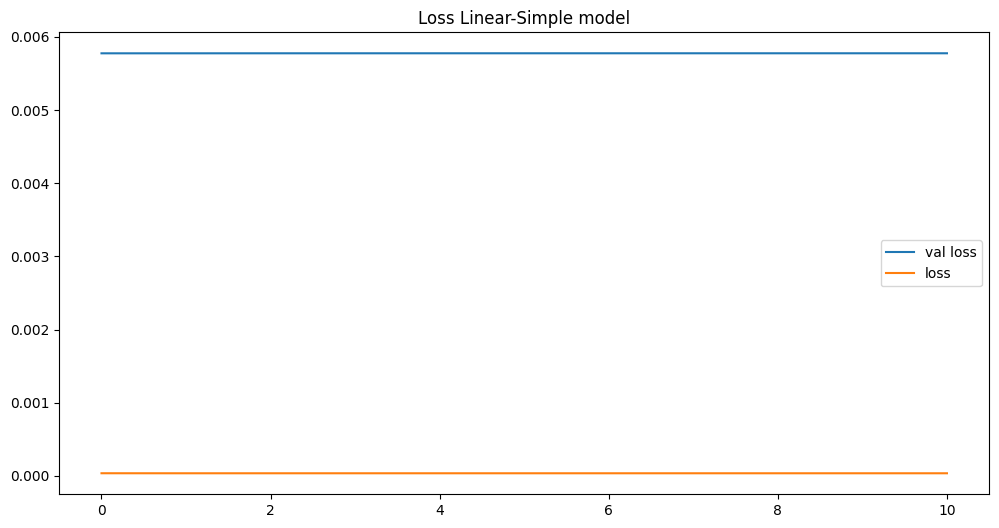

In [116]:
plot_training_validation(models_val["Linear_Uni"].history,"loss","Loss Linear-Simple model")

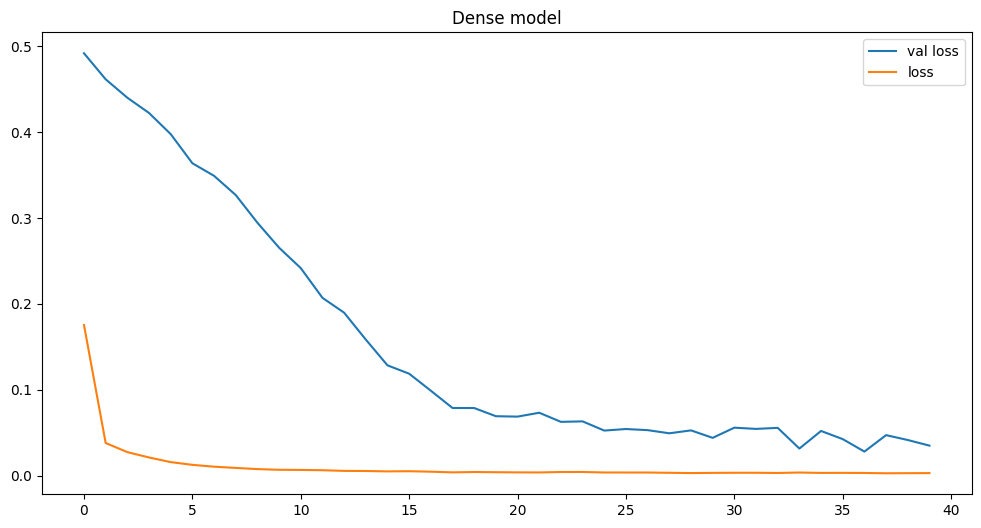

In [117]:
plot_training_validation(models_val["Dense"].history,"loss","Dense model")

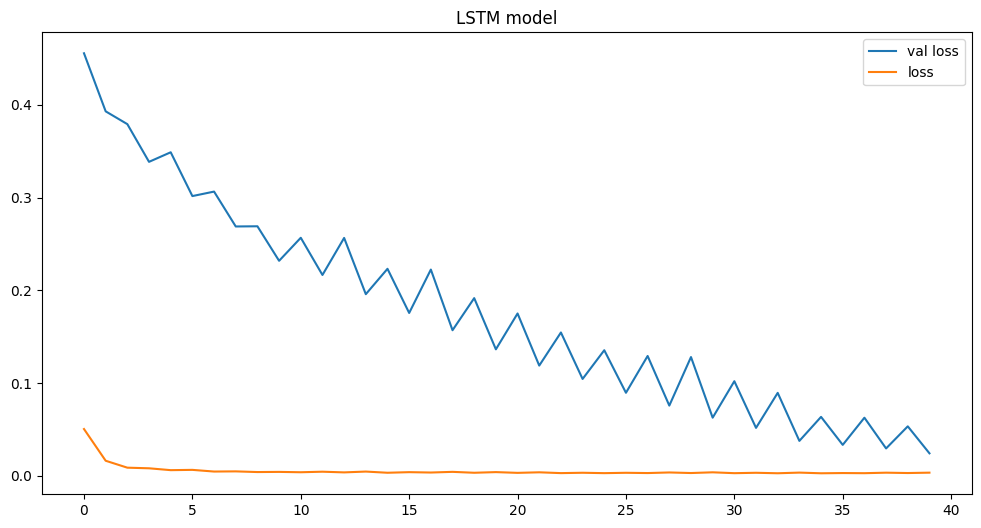

In [118]:
plot_training_validation(models_val["LSTM"].history,"loss","LSTM model")

In [119]:

df = import_joinTable(bdd,import_inflation_table(bdd))

df_model = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

In [120]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [121]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation"] = history_linear_inflation

Epoch 1/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5390 - mae: 0.6435 - val_loss: 0.3261 - val_mae: 0.4496
Epoch 2/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2799 - mae: 0.4169 - val_loss: 0.4458 - val_mae: 0.5434
Epoch 3/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1784 - mae: 0.3082 - val_loss: 0.5618 - val_mae: 0.6226
Epoch 4/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1208 - mae: 0.2531 - val_loss: 0.6186 - val_mae: 0.6640
Epoch 5/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0856 - mae: 0.2166 - val_loss: 0.6287 - val_mae: 0.6764
Epoch 6/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0641 - mae: 0.1899 - val_loss: 0.6025 - val_mae: 0.6598
Epoch 7/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0503 - mae: 0.1696 - val_loss: 0.5513 - val_mae: 0.6236
Epoch 8/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0408 - mae: 0.1535 - val_loss: 0.4873 - val_mae: 0.5789
Epoch 9/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.033

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


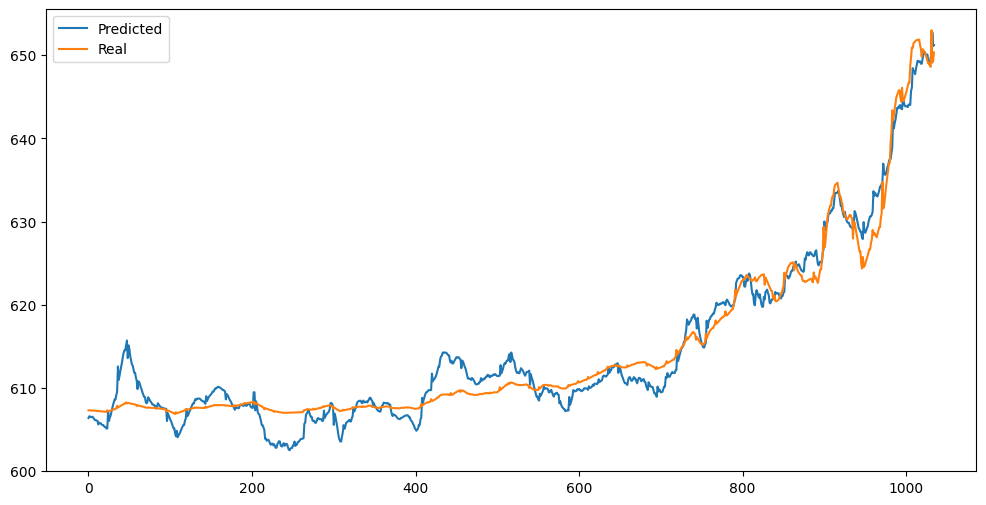

In [122]:
plot_prediction(wg_linear,model)


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


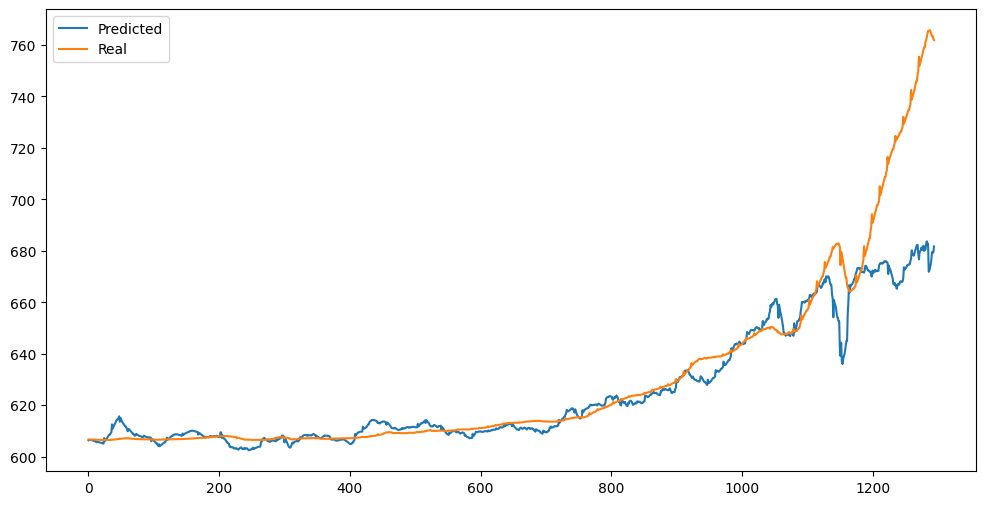

In [123]:
plot_prediction_test_general(wg_linear,model,target_index)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


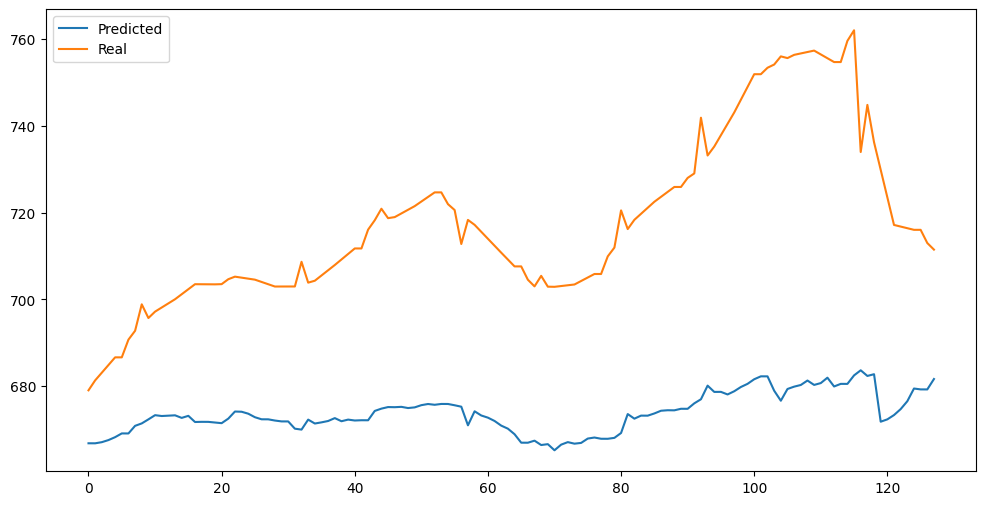

In [124]:
plot_prediction_test(wg_linear,model)

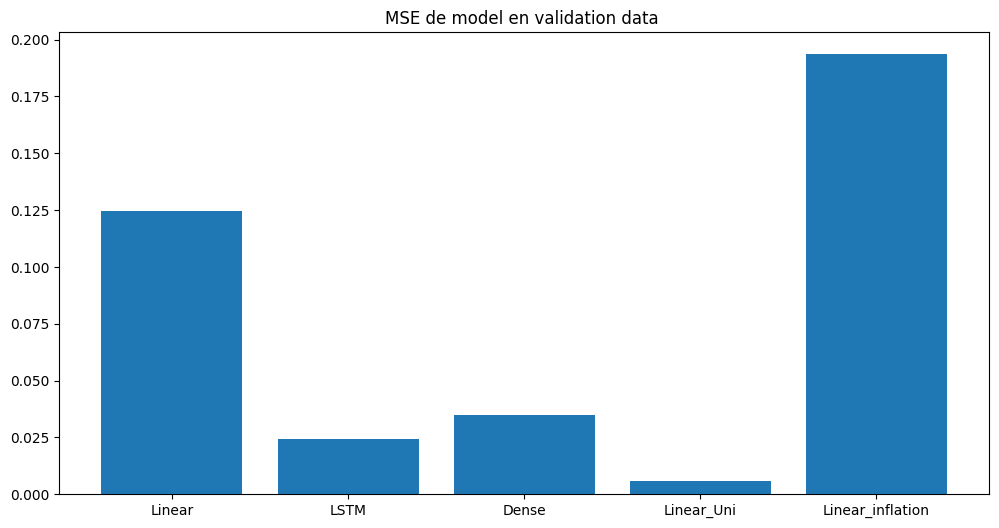

In [125]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

In [126]:

df = import_joinTable(bdd,import_inflation_table(bdd),import_bigmacindex_table(bdd))

df_model = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

In [127]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [128]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation_bigmac"] = history_linear_inflation

Epoch 1/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0985 - mae: 0.8552 - val_loss: 0.0475 - val_mae: 0.1823
Epoch 2/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0102 - mae: 0.8209 - val_loss: 0.0963 - val_mae: 0.2821
Epoch 3/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9411 - mae: 0.7965 - val_loss: 0.1539 - val_mae: 0.3724
Epoch 4/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8852 - mae: 0.7781 - val_loss: 0.2084 - val_mae: 0.4409
Epoch 5/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8376 - mae: 0.7611 - val_loss: 0.2545 - val_mae: 0.4914
Epoch 6/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7953 - mae: 0.7442 - val_loss: 0.2915 - val_mae: 0.5283
Epoch 7/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7566 - mae: 0.7275 - val_loss: 0.3204 - val_mae: 0.5554
Epoch 8/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7206 - mae: 0.7109 - val_loss: 0.3427 - val_mae: 0.5755
Epoch 9/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.68

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


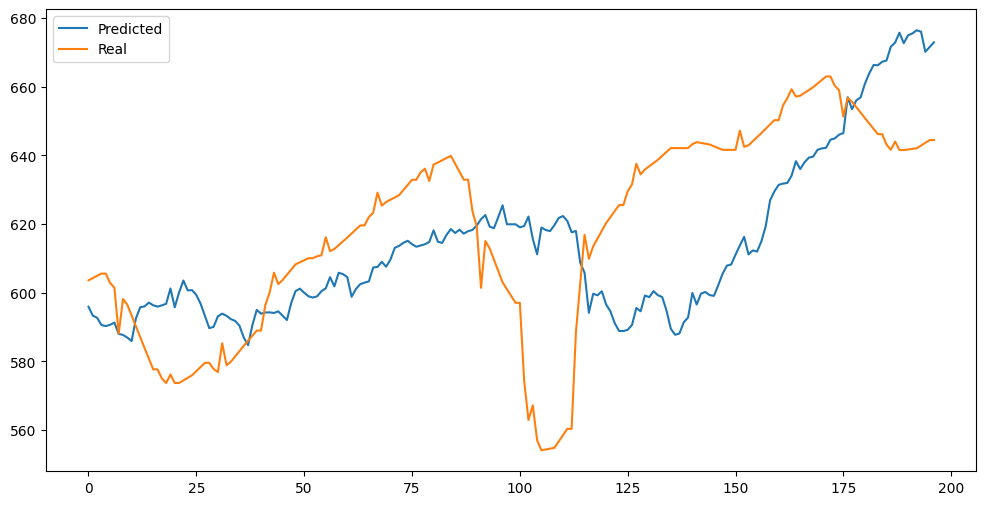

In [129]:
plot_prediction(wg_linear,model)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


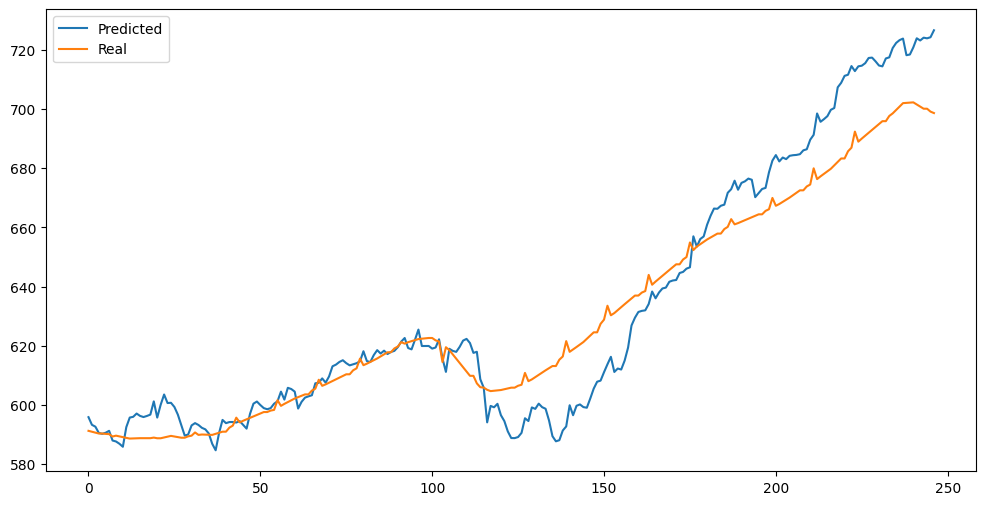

In [130]:
plot_prediction_test_general(wg_linear,model,target_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


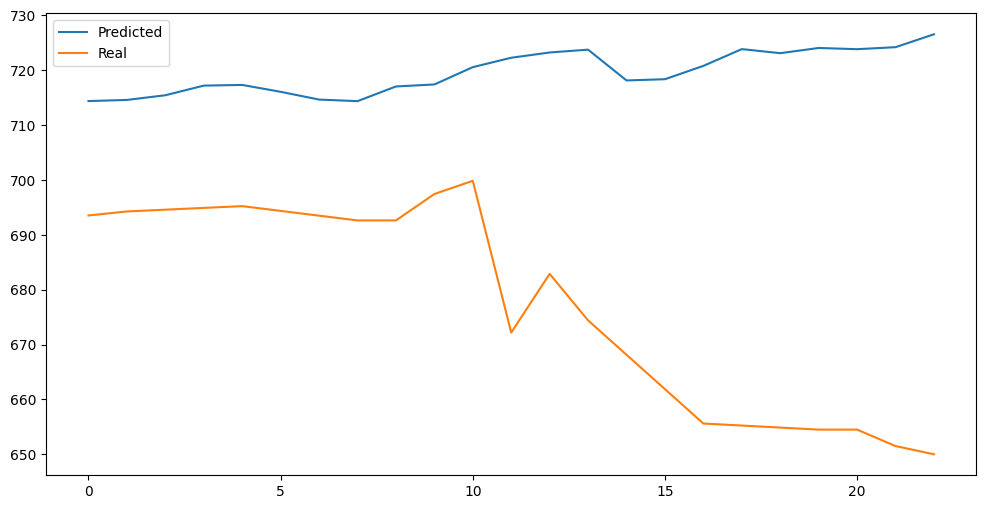

In [131]:
plot_prediction_test(wg_linear,model)

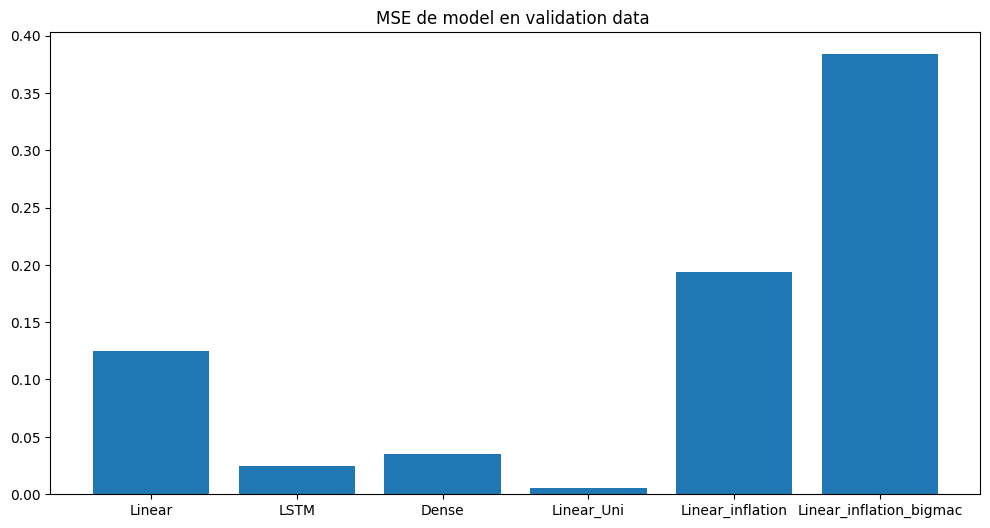

In [132]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")